<a href="https://colab.research.google.com/github/abdullahh-sheikhh/voxelmorph/blob/dev/scripts/cell_tracking/train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cell Deformation Estimation with VoxelMorph

2D deformable registration for PhC-C2DH-U373 cells using VoxelMorph, compared against Horn & Schunck classical optical flow baseline.

## 1. Setup

In [1]:
!git clone https://github.com/abdullahh-sheikhh/voxelmorph.git
%cd voxelmorph
!git checkout dev
!pip install -e . -q
!pip install imagecodecs -q

Cloning into 'voxelmorph'...
remote: Enumerating objects: 6193, done.
remote: Counting objects: 100% (798/798), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 6193 (delta 742), reused 668 (delta 668), pack-reused 5395 (from 4)
Receiving objects: 100% (6193/6193), 237.67 MiB | 25.72 MiB/s, done.
Resolving deltas: 100% (3626/3626), done.
/content/voxelmorph
Already on 'dev'
Your branch is up to date with 'origin/dev'.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Building editable for voxelmorph (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 80.5 MB/s eta 0:00:00


In [2]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4


## 2. Download Dataset

In [3]:
from pathlib import Path

!mkdir -p dataset

if not Path('dataset/train/01').exists():
    print('Downloading training data...')
    !wget -q https://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip -O dataset/train.zip
    !cd dataset && unzip -q train.zip -d train_raw && mv train_raw/PhC-C2DH-U373/* train/ && rm -rf train_raw train.zip
else:
    print('Training data already exists')

!echo "Train sequences:" && ls dataset/train/01/ | head -3 && echo "... (115 frames total)"

Training data already exists
Train sequences:
t000.tif
t001.tif
t002.tif
... (115 frames total)


## 3. Dataset Overview

What we are working with and what we are trying to do.

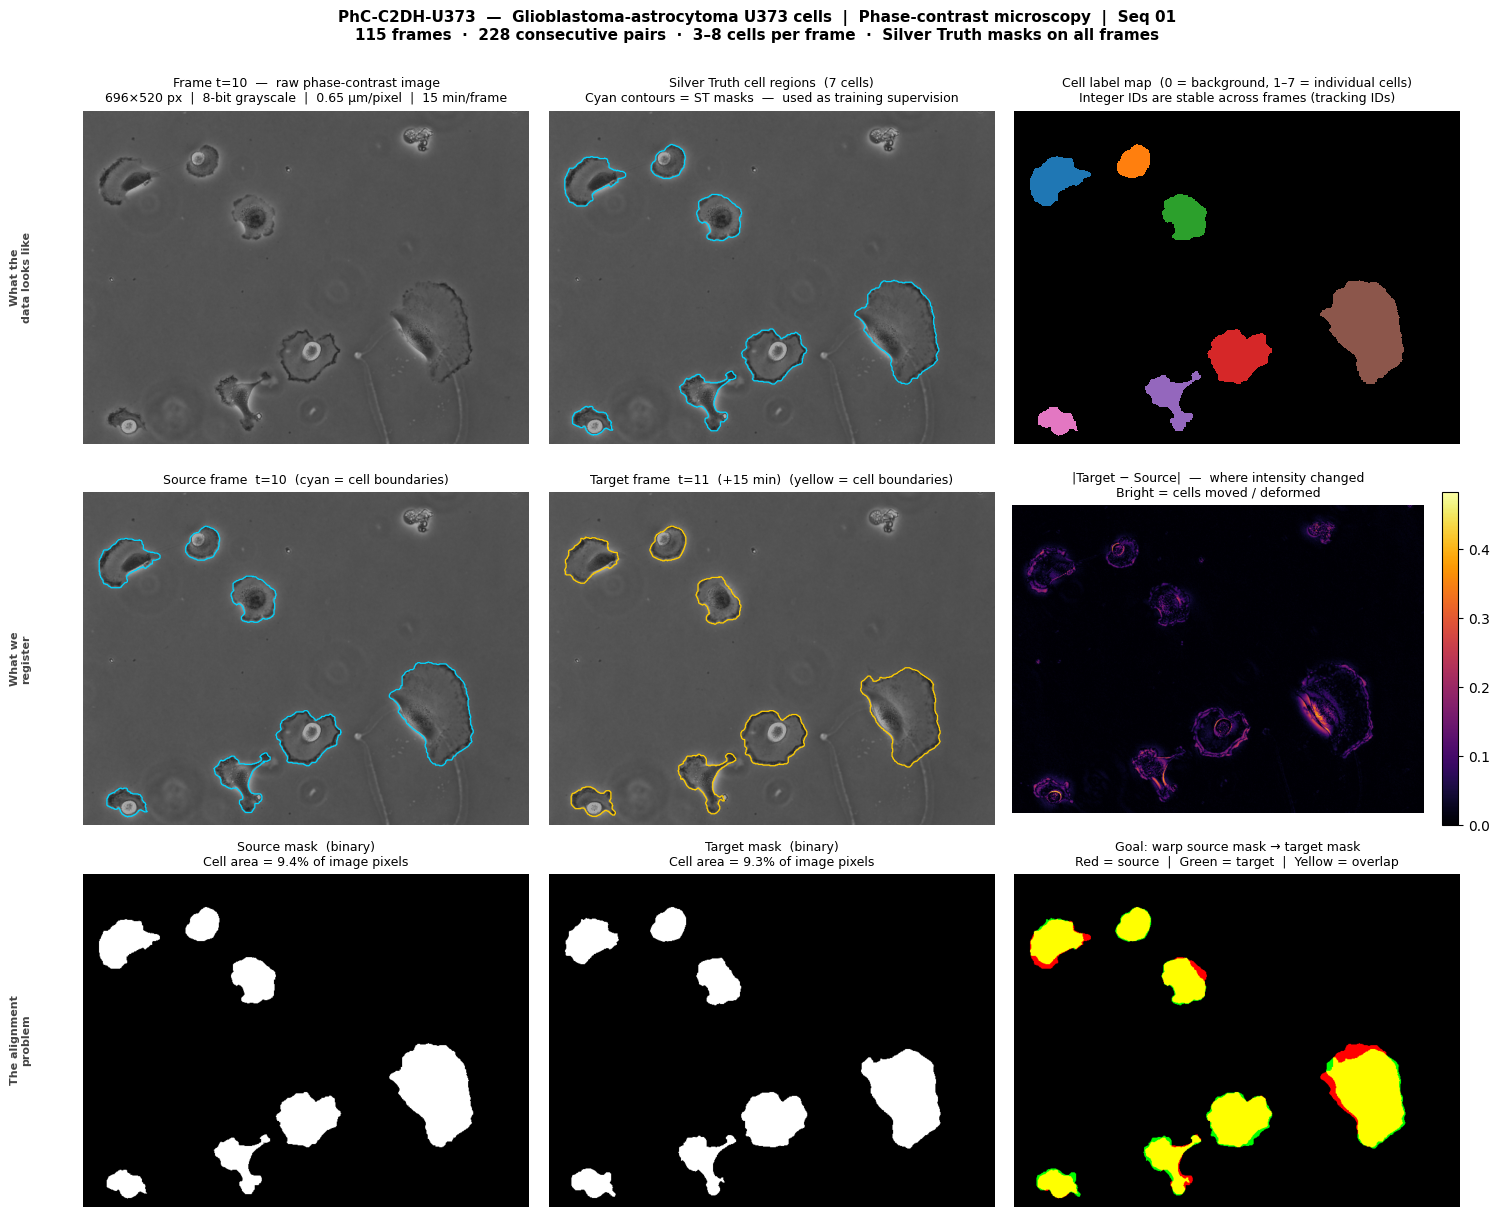

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from skimage import io
from pathlib import Path

#  Load two consecutive frames and their Silver Truth masks ─
frame_i, frame_j = 10, 11
seq_dir = Path('dataset/train/01')
st_dir  = Path('dataset/train/01_ST/SEG')

img_i  = io.imread(str(seq_dir / f't{frame_i:03d}.tif')).astype(np.float32) / 255.0
img_j  = io.imread(str(seq_dir / f't{frame_j:03d}.tif')).astype(np.float32) / 255.0
diff   = np.abs(img_j - img_i)

mask_i = io.imread(str(st_dir / f'man_seg{frame_i:03d}.tif')).astype(np.float32)
mask_j = io.imread(str(st_dir / f'man_seg{frame_j:03d}.tif')).astype(np.float32)

binary_i = mask_i > 0
binary_j = mask_j > 0
n_cells  = int(mask_i.max())

# Per-cell colour map: background = black, each cell = distinct colour
cell_cmap = ListedColormap(['black'] + [cm.tab10(i % 10) for i in range(n_cells)])

# Alignment overlay: red = source cells, green = target cells, yellow = overlap
align_rgb         = np.zeros((*img_i.shape, 3), dtype=np.float32)
align_rgb[..., 0] = binary_i.astype(float)
align_rgb[..., 1] = binary_j.astype(float)

#  Figure: 3 rows × 3 panels ─
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

kw_img = dict(cmap='gray', vmin=0, vmax=1)
kw_src = dict(colors=['#00d4ff'], linewidths=0.9, levels=[0.5])   # cyan  = source
kw_tgt = dict(colors=['#ffcc00'], linewidths=0.9, levels=[0.5])   # yellow = target

#  Row 0: single frame anatomy ─
axes[0, 0].imshow(img_i, **kw_img)
axes[0, 0].set_title(
    f'Frame t={frame_i}  —  raw phase-contrast image\n'
    f'696×520 px  |  8-bit grayscale  |  0.65 μm/pixel  |  15 min/frame', fontsize=9)

axes[0, 1].imshow(img_i, **kw_img)
axes[0, 1].contour(binary_i.astype(float), **kw_src)
axes[0, 1].set_title(
    f'Silver Truth cell regions  ({n_cells} cells)\n'
    f'Cyan contours = ST masks  —  used as training supervision', fontsize=9)

axes[0, 2].imshow(mask_i, cmap=cell_cmap, vmin=0, vmax=n_cells, interpolation='nearest')
axes[0, 2].set_title(
    f'Cell label map  (0 = background, 1–{n_cells} = individual cells)\n'
    f'Integer IDs are stable across frames (tracking IDs)', fontsize=9)

#  Row 1: consecutive pair
axes[1, 0].imshow(img_i, **kw_img)
axes[1, 0].contour(binary_i.astype(float), **kw_src)
axes[1, 0].set_title(f'Source frame  t={frame_i}  (cyan = cell boundaries)', fontsize=9)

axes[1, 1].imshow(img_j, **kw_img)
axes[1, 1].contour(binary_j.astype(float), **kw_tgt)
axes[1, 1].set_title(f'Target frame  t={frame_j}  (+15 min)  (yellow = cell boundaries)', fontsize=9)

im = axes[1, 2].imshow(diff, cmap='inferno', vmin=0, vmax=diff.max())
axes[1, 2].set_title('|Target − Source|  —  where intensity changed\nBright = cells moved / deformed', fontsize=9)
fig.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

#  Row 2: the registration problem ─
axes[2, 0].imshow(binary_i.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 0].set_title(
    f'Source mask  (binary)\n'
    f'Cell area = {binary_i.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 1].imshow(binary_j.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2, 1].set_title(
    f'Target mask  (binary)\n'
    f'Cell area = {binary_j.mean()*100:.1f}% of image pixels', fontsize=9)

axes[2, 2].imshow(align_rgb)
axes[2, 2].set_title(
    'Goal: warp source mask → target mask\n'
    'Red = source  |  Green = target  |  Yellow = overlap', fontsize=9)

#  Row labels & final formatting ─
row_labels = ['What the\ndata looks like', 'What we\nregister', 'The alignment\nproblem']
for row, label in enumerate(row_labels):
    axes[row, 0].annotate(
        label, xy=(-0.14, 0.5), xycoords='axes fraction',
        ha='center', va='center', fontsize=8, fontweight='bold',
        rotation=90, color='#444444')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(
    'PhC-C2DH-U373  —  Glioblastoma-astrocytoma U373 cells  |  Phase-contrast microscopy  |  Seq 01\n'
    '115 frames  ·  228 consecutive pairs  ·  3–8 cells per frame  ·  Silver Truth masks on all frames',
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Train — Masked MSE

Train **Masked MSE** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks (primary alignment signal)
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 0.01` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss mse --lambda 0.01 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/masked_mse \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/masked_mse/loss_curve.png', width=800))

## 5. Train — Normalized Cross-Correlation

Train **Normalized Cross-Correlation** for 200 epochs on sequence 01.

Loss terms:
- `--mask-weight 1.0` — soft Dice on cell masks
- `--int-weight 0.1` — cell-restricted intensity loss
- `--lambda 1.0` — displacement field smoothness regularisation

In [ ]:
!python -m scripts.cell_tracking.train \
    --data-dir dataset/train \
    --sequences 01 \
    --epochs 200 --batch-size 4 --lr 1e-4 \
    --loss ncc --lambda 1.0 \
    --mask-weight 1.0 --int-weight 0.1 \
    --output-dir output/ncc \
    --save-every 50

In [ ]:
from IPython.display import Image, display
display(Image(filename='output/ncc/loss_curve.png', width=800))

## 6. Evaluate — Masked MSE

Evaluate on held-out sequence 02. Includes Horn & Schunck baseline.

In [ ]:
!python -m scripts.cell_tracking.evaluate \
    --model output/masked_mse/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_masked_mse \
    --max-pairs 0

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_masked_mse').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

## 7. Evaluate — Normalized Cross-Correlation

Evaluate on held-out sequence 02. Horn & Schunck numbers reused from section 6.

In [ ]:
!python -m scripts.cell_tracking.evaluate \
    --model output/ncc/best.pt \
    --data-dir dataset/train \
    --gt-dir dataset/train \
    --sequences 02 \
    \
    --output-dir output/eval_ncc \
    --no-baselines \
    --max-pairs 0

In [ ]:
from IPython.display import Image, display
from pathlib import Path

for img_path in sorted(Path('output/eval_ncc').glob('pair_*.png'))[:3]:
    print(img_path.name)
    display(Image(filename=str(img_path), width=900))

## 8. Results

Comparison across methods evaluated on sequence 02 (held-out from training).

In [ ]:
import json
import pandas as pd
from pathlib import Path


def load_metrics(path: str, key: str) -> dict | None:
    p = Path(path)
    if not p.exists():
        return None
    return json.loads(p.read_text()).get(key)


def fmt(metrics: dict) -> dict:
    dice = (
        f"{metrics['dice_mean']:.4f} \u00b1 {metrics['dice_std']:.4f}"
        if 'dice_mean' in metrics else '\u2014'
    )
    masked_mse = (
        f"{metrics['masked_mse_mean']:.6f} \u00b1 {metrics['masked_mse_std']:.6f}"
        if 'masked_mse_mean' in metrics else '\u2014'
    )
    runtime = (
        f"{metrics['runtime_mean']:.4f}"
        if 'runtime_mean' in metrics else '\u2014'
    )
    return {'Dice': dice, 'Masked MSE': masked_mse, 'Runtime (s)': runtime}


rows = []

hs = load_metrics('output/eval_masked_mse/metrics.json', 'horn_schunck')
if hs:
    rows.append({'Method': 'Horn & Schunck', **fmt(hs)})

for name, eval_dir in [
    ('Masked MSE',                   'output/eval_masked_mse'),
    ('Normalized Cross-Correlation', 'output/eval_ncc'),
]:
    m = load_metrics(f'{eval_dir}/metrics.json', 'vxm')
    if m:
        rows.append({'Method': name, **fmt(m)})

pd.DataFrame(rows).set_index('Method')